In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from xgboost import XGBRegressor

import shap

from catboost import CatBoostRegressor

from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

from sklearn.svm import SVR

from sklearn.linear_model import Ridge

from sklearn.preprocessing import StandardScaler

In [2]:
import random

SEED = 42
random.seed(SEED)           
np.random.seed(SEED)        

In [3]:
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

print(PROCESSED_DIR)

C:\Users\Sameen\10 Pearls Project\AQI Predictor\Data\Processed


In [4]:
# df = pd.read_csv(PROCESSED_DIR / "Aqi_Data_Two_Day_Prediction_New.csv", index_col="time", parse_dates=True)
# df.info()

In [5]:
# df.head()

# Train And Test Split

In [6]:
# df.columns

In [7]:
# X = df.drop(columns = ['Day_2_Future_AQI'])
# Y = df['Day_2_Future_AQI']

In [8]:
# X

In [9]:
# Y

In [10]:
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

In [11]:
# len(X_train)

In [12]:
# len(X_test)

# Building XGBoost Model For Day Two

In [13]:
# model = XGBRegressor(n_estimators = 520, 
#                      learning_rate = 0.033,
#                      max_depth = 3, 
#                      random_state = 42, 
#                      colsample_bytree = 0.7, 
#                      subsample = 0.7,
#                      min_child_weight = 5,
#                      gamma=0.1,
#                      reg_alpha=0.1,
#                      reg_lambda=1.5,
#                     ) 

In [14]:
# model.fit(X_train, Y_train)

In [15]:
# y_pred = model.predict(X_test)

# Evaluating the Model

In [16]:
# R2_Score = r2_score(Y_test, y_pred)
# Mae = mean_absolute_error(Y_test, y_pred)
# Mean_Square_Error = mean_squared_error(Y_test, y_pred)
# Root_Mean_Square_Error = np.sqrt(Mean_Square_Error)

# print("Evaluation Metrics: ")
# print(f"R2 Score: {R2_Score}")
# print(f"Mean Absolute Error: {Mae}")
# print(f"Mean Square Error: {Mean_Square_Error}")
# print(f"Root Mean Square Error: {Root_Mean_Square_Error}")

# Note:
- Not much Improvement will come even if I do hyper parameter optimization. I will try other method

# Now Day Wise

In [17]:
import os
from dotenv import load_dotenv
import hopsworks

In [18]:
load_dotenv(PROJECT_ROOT / ".env")

key = os.getenv("HOPSWORK_KEY")

In [19]:
project = hopsworks.login(
    project='aqi_karachi_samu_2026',
    host="eu-west.cloud.hopsworks.ai",
    port=443,
    api_key_value=key,
)

fs = project.get_feature_store()
print(f"Connected to {project.name}")

2026-08-26 00:35:08,352 INFO: Initializing external client
2026-08-26 00:35:08,353 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-26 00:35:11,898 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41193
Connected to aqi_karachi_samu_2026


In [20]:
target = "day_2_future_aqi"
day_2_fv = fs.get_feature_view(name="view_aqi_day2", version=1)

In [21]:
x, y = day_2_fv.training_data()

Reading data from Hopsworks, using Hopsworks Feature Query Service...   

2026-08-26 00:35:24,686 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (3.23s) 


In [22]:
day2 = x.copy()
day2[target] = y[target]

In [23]:
day2.time = pd.to_datetime(day2.time)
day2 = day2.sort_values("time").set_index("time")

In [24]:
day2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1090 entries, 2023-08-04 00:00:00+00:00 to 2026-07-28 00:00:00+00:00
Data columns (total 52 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_2m               1090 non-null   float64
 1   wind_speed_10m               1090 non-null   float64
 2   relative_humidity_2m         1090 non-null   float64
 3   surface_pressure             1090 non-null   float64
 4   boundary_layer_height        909 non-null    float64
 5   dew_point_2m                 1090 non-null   float64
 6   precipitation                1090 non-null   float64
 7   cloud_cover                  1090 non-null   float64
 8   wind_direction_10m           1090 non-null   float64
 9   wind_gusts_10m               1090 non-null   float64
 10  shortwave_radiation          1090 non-null   float64
 11  pm10                         1090 non-null   float64
 12  pm2_5                       

In [25]:
day2.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height,day_2_future_aqi
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333,147.708333,78.833333
2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667,98.125000,78.875000
2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667,-95.000000,78.791667
2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667,-117.708333,73.416667
2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667,-29.375000,68.791667


In [26]:
day2.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'month', 'dayofweek',
       'previous_day_aqi', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr', 'ewm_aqi_24hr',
       'ewm_std_24hr', 'f48_temperature_2m', 'f48_wind_speed_10m',
       'f48_relative_humidity_2m', 'f48_surface_pressure',
       'f48_boundary_layer_height', 'f48_dew_point_2m', 'f48_precipitation',
       'f48_cloud_cover', 'f48_wind_gusts_10m', 'f48_shortwave_radiation',
       'wind_pollution_dispersion', 'pressure_change_3hour', 'humidity_level',
       'cyclic_day_sin', 'cyclic_day_cos', 'cyclic_week_sin',
       'cyclic_week_cos', 'del

In [27]:
X1 = day2.drop(columns = [target])
Y1 = day2[target]

In [28]:
X1 = X1.drop(columns = ["boundary_layer_height","f48_boundary_layer_height","wind_pollution_dispersion","delta_boundary_layer_height"])

In [29]:
X1

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,shortwave_radiation,...,pressure_change_3hour,humidity_level,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,25.291667,0.037500,50.083333,245.083333,31.941667,223.041667,...,0.225000,3.150000,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333
2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,24.866667,0.037500,69.833333,247.750000,33.450000,220.291667,...,0.266667,3.462500,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667
2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,24.479167,0.029167,81.625000,254.500000,45.562500,175.958333,...,-0.387500,3.754167,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667
2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,24.266667,0.070833,75.000000,250.250000,49.770833,171.375000,...,-0.200000,3.775000,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667
2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,24.512500,0.091667,68.541667,245.916667,44.275000,172.000000,...,0.304167,3.483333,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24 00:00:00+00:00,30.233333,9.304167,76.625000,997.970833,25.545833,0.000000,77.375000,233.250000,26.816667,250.166667,...,0.104167,4.687500,-0.377708,-0.925925,-0.433884,-0.900969,-0.545833,1.162500,2.883333,-3.625000
2026-07-25 00:00:00+00:00,29.541667,10.587500,76.500000,999.633333,24.916667,0.000000,98.833333,244.375000,28.675000,156.333333,...,0.262500,4.625000,-0.393590,-0.919286,-0.974928,-0.222521,0.287500,3.675000,0.229167,-3.375000
2026-07-26 00:00:00+00:00,29.687500,10.466667,73.000000,1000.854167,24.254167,0.000000,78.416667,262.625000,27.916667,193.875000,...,0.050000,5.433333,-0.409356,-0.912375,-0.781831,0.623490,-0.237500,5.154167,-3.266667,2.458333


In [30]:
Y1

time
2023-08-04 00:00:00+00:00    78.833333
2023-08-05 00:00:00+00:00    78.875000
2023-08-06 00:00:00+00:00    78.791667
2023-08-07 00:00:00+00:00    73.416667
2023-08-08 00:00:00+00:00    68.791667
                               ...    
2026-07-24 00:00:00+00:00    82.041667
2026-07-25 00:00:00+00:00    83.250000
2026-07-26 00:00:00+00:00    78.708333
2026-07-27 00:00:00+00:00    79.125000
2026-07-28 00:00:00+00:00    80.416667
Name: day_2_future_aqi, Length: 1090, dtype: float64

In [31]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, shuffle = False)

In [32]:
len(X_train1)

872

In [33]:
len(X_test1)

218

# Building XGBoost Model For Day Two

## The All Model :)

In [34]:
model_all = XGBRegressor(n_estimators = 520, 
                         learning_rate = 0.033,
                         max_depth = 3, 
                         random_state = 42, 
                         colsample_bytree = 0.7, 
                         subsample = 0.7,
                         min_child_weight = 5,
                         gamma=0.1,
                         reg_alpha=0.1,
                         reg_lambda=1.5,
                        ) 

model_all.fit(X_train1, Y_train1)
y_pred_all = model_all.predict(X_test1)

In [35]:
R2_Score_All = r2_score(Y_test1, y_pred_all)
Mae_All = mean_absolute_error(Y_test1, y_pred_all)
Mean_Square_Error_All = mean_squared_error(Y_test1, y_pred_all)
Root_Mean_Square_Error_All = np.sqrt(Mean_Square_Error_All)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score_All}")
print(f"Mean Absolute Error: {Mae_All}")
print(f"Mean Square Error: {Mean_Square_Error_All}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error_All}")

Evaluation Metrics: 
R2 Score: 0.5049781960190423
Mean Absolute Error: 9.429890460559719
Mean Square Error: 177.93797658120243
Root Mean Square Error: 13.33933943571429


## 1. By Validation:

In [36]:
validation = 150

X_fit, X_validation = X_train1.iloc[0:722], X_train1.iloc[722:872]
Y_fit, Y_validation = Y_train1.iloc[0:722], Y_train1.iloc[722:872]

In [37]:
model1 = XGBRegressor(
    n_estimators = 3000,   
    learning_rate = 0.02,
    max_depth = 3,
    min_child_weight = 20,
    gamma = 1.0,
    subsample = 0.7,
    colsample_bytree = 0.5,
    reg_alpha = 0.5,
    reg_lambda = 10,
    random_state = 42,
    n_jobs = -1,
    early_stopping_rounds = 100,  
    eval_metric = "rmse",
)

model1.fit(X_fit, Y_fit, eval_set = [(X_validation, Y_validation)], verbose = False)
y_pred1 = model1.predict(X_test1)

In [38]:
R2_Score1 = r2_score(Y_test1, y_pred1)
Mae1 = mean_absolute_error(Y_test1, y_pred1)
Mean_Square_Error1 = mean_squared_error(Y_test1, y_pred1)
Root_Mean_Square_Error1 = np.sqrt(Mean_Square_Error1)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score1}")
print(f"Mean Absolute Error: {Mae1}")
print(f"Mean Square Error: {Mean_Square_Error1}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error1}")

Evaluation Metrics: 
R2 Score: 0.5242953721274033
Mean Absolute Error: 9.310051430985103
Mean Square Error: 170.99432439792056
Root Mean Square Error: 13.07647981675193


### R2 Score less select only important features

In [39]:
imp_features = pd.Series(model1.feature_importances_, index = X_fit.columns).sort_values(ascending = False)

In [40]:
imp_features.head(30)

cyclic_day_cos                0.129610
pm2_5                         0.115566
f48_surface_pressure          0.057375
f48_dew_point_2m              0.056567
ewm_aqi_24hr                  0.050001
us_aqi                        0.036950
aerosol_optical_depth         0.029125
f48_wind_gusts_10m            0.026090
f48_relative_humidity_2m      0.025996
wind_direction_10m            0.023245
f48_shortwave_radiation       0.022993
rolled_mean_aqi_24hr          0.021705
pm10                          0.020938
f48_wind_speed_10m            0.019129
delta_wind_speed_10m          0.017273
f48_temperature_2m            0.016394
cyclic_day_sin                0.016325
shortwave_radiation           0.015641
dust                          0.014999
surface_pressure              0.013335
dew_point_2m                  0.012833
delta_relative_humidity_2m    0.012621
month                         0.012482
delta_surface_pressure        0.012040
rolled_std_aqi_24hr           0.011784
relative_humidity_2m     

## 2. By Important Features:

In [41]:
# for top in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47]:
#     top_features = imp_features.head(top).index.tolist()

#     model_imp = XGBRegressor(
#     n_estimators = 3000,   
#     learning_rate = 0.02,
#     max_depth = 3,
#     min_child_weight = 20,
#     gamma = 1.0,
#     subsample = 0.7,
#     colsample_bytree = 0.7,
#     reg_alpha = 0.5,
#     reg_lambda = 10,
#     random_state = 42,
#     n_jobs = -1,
#     early_stopping_rounds = 100,  
#     eval_metric = "rmse",
#     )
    
#     model_imp.fit(X_fit[top_features], Y_fit, eval_set = [(X_validation[top_features], Y_validation)], verbose = False)
    
#     Validation_R2_Score = r2_score(Y_validation, model_imp.predict(X_validation[top_features]))
#     Test_R2_Score = r2_score(Y_test1, model_imp.predict(X_test1[top_features]))
    
#     Validation_Mean_Absolute_Score = mean_absolute_error(Y_validation, model_imp.predict(X_validation[top_features]))
#     Test_Mean_Absolute_Score = mean_absolute_error(Y_test1, model_imp.predict(X_test1[top_features]))

#     Validation_Mean_Square_Score = mean_squared_error(Y_validation, model_imp.predict(X_validation[top_features]))
#     Test_Mean_Square_Score = mean_squared_error(Y_test1, model_imp.predict(X_test1[top_features]))
    
#     Validation_Root_Mean_Square_Score = np.sqrt(mean_squared_error(Y_validation, model_imp.predict(X_validation[top_features])))
#     Test_Root_Mean_Square_Score = np.sqrt(mean_squared_error(Y_test1, model_imp.predict(X_test1[top_features])))

#     print(f"""{top}: Validation R2 Score: {Validation_R2_Score} \n
#                Test R2 Score: {Test_R2_Score} \n
#                Validation Mean Absolute Score: {Validation_Mean_Absolute_Score} \n
#                Test Mean Absolute Score: {Test_Mean_Absolute_Score} \n
#                Validation Mean Square Score: {Validation_Mean_Square_Score} \n
#                Test Mean Square Score: {Test_Mean_Square_Score} \n
#                Validation Root Mean Square Score: {Validation_Root_Mean_Square_Score} \n
#                Test Root Mean Square Score: {Test_Root_Mean_Square_Score} \n """)

#### Note: No such improvement

### 3. CatBoost Blend With All Model

In [42]:
cbr1 = CatBoostRegressor(iterations = 3000,
                        learning_rate = 0.02,
                        depth = 4,
                        l2_leaf_reg = 10,
                        random_seed = 42,
                        early_stopping_rounds = 100,
                        verbose = False,)

cbr1.fit(X_fit, Y_fit, eval_set = [(X_validation, Y_validation)], verbose = False)
y_pred_cbr = cbr1.predict(X_test1)

In [43]:
blend = 0.5 * y_pred_all + 0.5 * y_pred_cbr 

In [44]:
print("Cat Boost: ")
R2_Score_Cat = r2_score(Y_test1, y_pred_cbr)
Mae_Cat = mean_absolute_error(Y_test1, y_pred_cbr)
Mean_Square_Error_Cat = mean_squared_error(Y_test1, y_pred_cbr)
Root_Mean_Square_Error_Cat = np.sqrt(Mean_Square_Error_Cat)
print(f"Cat Boost R2 Score: {R2_Score_Cat}")
print(f"Cat Boost Mean Absolute Error: {Mae_Cat}")
print(f"Cat Boost Mean Square Error: {Mean_Square_Error_Cat}")
print(f"Cat Boost Root Mean Square Error: {Root_Mean_Square_Error_Cat}")

print("Blend: ")
R2_Score_Blend = r2_score(Y_test1, blend)
Mae_Blend = mean_absolute_error(Y_test1, blend)
Mean_Square_Error_Blend = mean_squared_error(Y_test1, blend)
Root_Mean_Square_Error_Blend = np.sqrt(Mean_Square_Error1)
print(f"Blend R2 Score: {R2_Score_Blend}")
print(f"Blend Mean Absolute Error: {Mae_Blend}")
print(f"Blend Mean Square Error: {Mean_Square_Error_Blend}")
print(f"Blend Root Mean Square Error: {Root_Mean_Square_Error_Blend}")

Cat Boost: 
Cat Boost R2 Score: 0.5285094206636949
Cat Boost Mean Absolute Error: 9.394259522539757
Cat Boost Mean Square Error: 169.47956431314748
Cat Boost Root Mean Square Error: 13.018431714809102
Blend: 
Blend R2 Score: 0.5350747995526666
Blend Mean Absolute Error: 9.265531374038098
Blend Mean Square Error: 167.11960718479946
Blend Root Mean Square Error: 13.07647981675193


### 4. CatBoost + XG All + RF + SVR + RIDGE

In [45]:
rf = RandomForestRegressor(
    n_estimators = 500,
    max_depth = 8,
    min_samples_leaf = 10,      
    max_features = 0.5,        
    random_state = 42,
    n_jobs = -1,
)

rf.fit(X_train1, Y_train1)
pred_rf = rf.predict(X_test1)

R2_Score_Rf = r2_score(Y_test1, pred_rf)
Mae_Rf = mean_absolute_error(Y_test1, pred_rf)
Mean_Square_Error_Rf = mean_squared_error(Y_test1, pred_rf)
Root_Mean_Square_Error_Rf = np.sqrt(Mean_Square_Error_Rf)

print("Random Forest Evaluation Metrics: ")
print(f"R2 Score: {R2_Score_Rf}")
print(f"Mean Absolute Error: {Mae_Rf}")
print(f"Mean Square Error: {Mean_Square_Error_Rf}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error_Rf}")

Random Forest Evaluation Metrics: 
R2 Score: 0.5372286927073102
Mean Absolute Error: 9.508453950953097
Mean Square Error: 166.34537989495644
Root Mean Square Error: 12.897495101567452


In [46]:
sc = StandardScaler()
X_train_clean = sc.fit_transform(X_train1)
X_test_clean = sc.transform(X_test1)

In [47]:
ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(X_train_clean, Y_train1)

y_pred_ridge = ridge_model.predict(X_test_clean)

R2_Score_Ridge = r2_score(Y_test1, y_pred_ridge)
Mae_Ridge = mean_absolute_error(Y_test1, y_pred_ridge)
Mean_Square_Error_Ridge = mean_squared_error(Y_test1, y_pred_ridge)
Root_Mean_Square_Error_Ridge = np.sqrt(Mean_Square_Error_Ridge)

print("Ridge Regression Evaluation Metrics: ")
print(f"R2 Score: {R2_Score_Ridge}")
print(f"Mean Absolute Error: {Mae_Ridge}")
print(f"Mean Square Error: {Mean_Square_Error_Ridge}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error_Ridge}")

Ridge Regression Evaluation Metrics: 
R2 Score: 0.47887856734782297
Mean Absolute Error: 9.855776084606607
Mean Square Error: 187.31961407258078
Root Mean Square Error: 13.686475589887294


In [48]:
bagSVM = BaggingRegressor(estimator = SVR(kernel='rbf', C=100, epsilon=1.0),
                        n_estimators = 500,
                        max_samples = 0.25,
                        bootstrap = True,
                        random_state = 42,
                        n_jobs = -1)

bagSVM.fit(X_train_clean, Y_train1)
y_pred_bagSVM = bagSVM.predict(X_test_clean)

R2_Score_SVM = r2_score(Y_test1, y_pred_bagSVM)
Mae_SVM = mean_absolute_error(Y_test1, y_pred_bagSVM)
Mean_Square_Error_SVM = mean_squared_error(Y_test1, y_pred_bagSVM)
Root_Mean_Square_Error_SVM = np.sqrt(Mean_Square_Error_SVM)

print("SVM Evaluation Metrics: ")
print(f"R2 Score: {R2_Score_SVM}")
print(f"Mean Absolute Error: {Mae_SVM}")
print(f"Mean Square Error: {Mean_Square_Error_SVM}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error_SVM}")

SVM Evaluation Metrics: 
R2 Score: 0.5319032838192004
Mean Absolute Error: 9.434988912993722
Mean Square Error: 168.25962382198605
Root Mean Square Error: 12.971492736843592


In [49]:
blend5 = (y_pred_all + y_pred_cbr + pred_rf + y_pred_ridge + y_pred_bagSVM) / 5

R2_Score_blend5 = r2_score(Y_test1, blend5)
Mae_blend5 = mean_absolute_error(Y_test1, blend5)
Mean_Square_Error_blend5 = mean_squared_error(Y_test1, blend5)
Root_Mean_Square_Error_blend5 = np.sqrt(Mean_Square_Error_blend5)

print("Blend Evaluation Metrics: ")
print(f"R2 Score: {R2_Score_blend5}")
print(f"Mean Absolute Error: {Mae_blend5}")
print(f"Mean Square Error: {Mean_Square_Error_blend5}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error_blend5}")

Blend Evaluation Metrics: 
R2 Score: 0.553058344810298
Mean Absolute Error: 9.164951933021673
Mean Square Error: 160.65533504735942
Root Mean Square Error: 12.674988562020852


# Baseline Prediction For Day Two

In [50]:
y_pred_baseline = X_test1['us_aqi']
R2_Score_baseline = r2_score(Y_test1, y_pred_baseline)

In [51]:
R2_Score_baseline

0.1901201067864633

### So the Gain

In [52]:
R2_Score1 - R2_Score_baseline

0.33417526534094

# SHAP STEP

### GET SHAP VALUES

In [53]:
explainer = shap.Explainer(model_all)
shap_values = explainer(X_test1)

### Waterfall Model

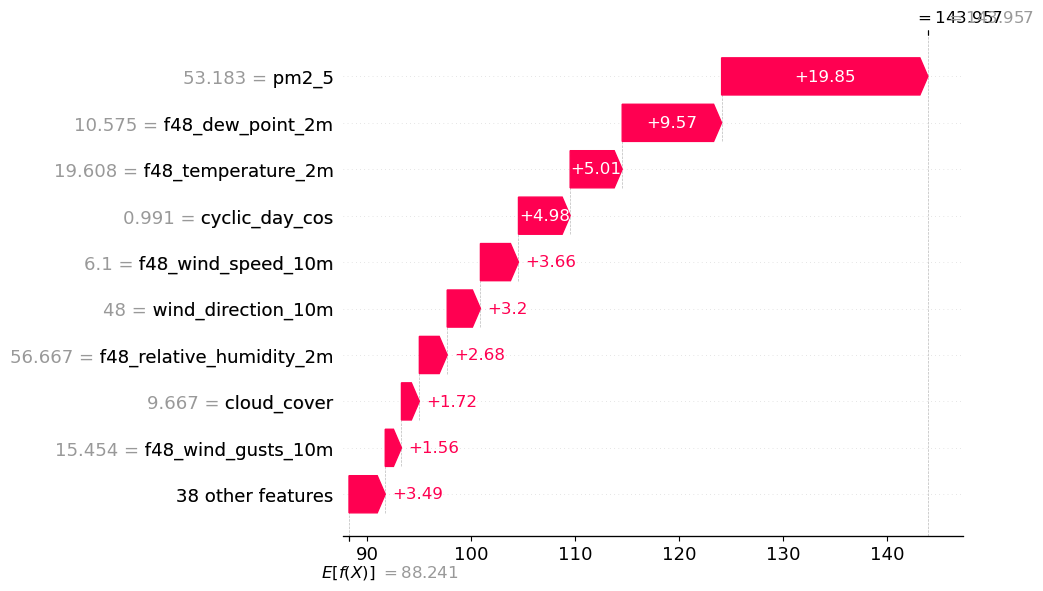

In [54]:
shap.plots.waterfall(shap_values[0])

### Beeswarm Plot

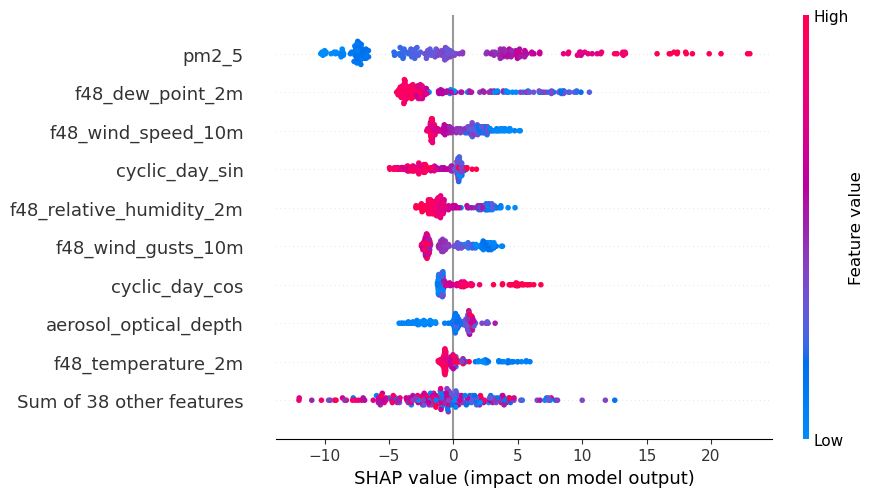

In [55]:
shap.plots.beeswarm(shap_values)

# Prediction Chart

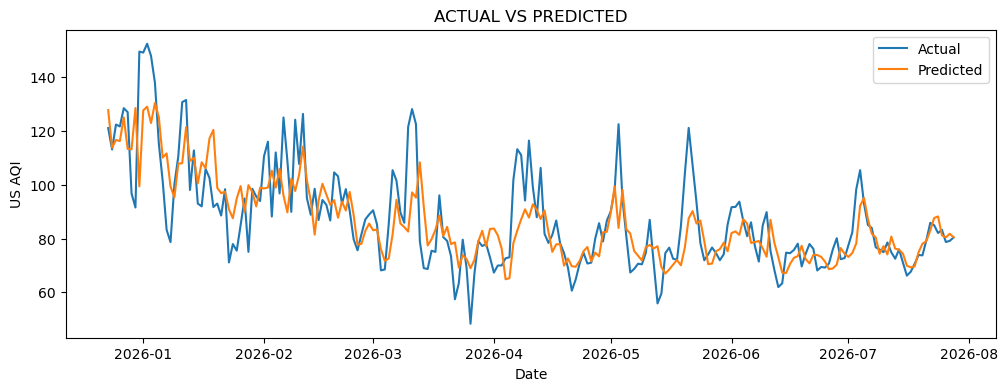

In [56]:
plt.figure(figsize=(12,4))
plt.plot(Y_test1.index, Y_test1.values, label="Actual")
plt.plot(Y_test1.index, blend5, label="Predicted")
plt.legend(loc = "best")
plt.title("ACTUAL VS PREDICTED")
plt.ylabel("US AQI")
plt.xlabel("Date")
plt.show()

# Overfitting Test

In [57]:
train_all   = model_all.predict(X_train1)
train_cbr   = cbr1.predict(X_train1)
train_rf    = rf.predict(X_train1)
train_ridge = ridge_model.predict(X_train_clean)
train_svm   = bagSVM.predict(X_train_clean)

blend5_train = (train_all + train_cbr + train_rf + train_ridge + train_svm) / 5

train_Score = r2_score(Y_train1, blend5_train)
test_Score  = r2_score(Y_test1, blend5)

print(f"Train R2 : {train_Score}")
print(f"Test  R2 : {test_Score}")
print(f"Gap Overfit Check : {train_Score - test_Score}")

Train R2 : 0.7889333471210783
Test  R2 : 0.553058344810298
Gap Overfit Check : 0.2358750023107803
